# Exploratory Data Analysis - Heart Disease Dataset

This notebook explores the heart disease dataset to understand its structure, check for data quality issues, and identify patterns before building predictive models.

In [65]:
# Import libraries we'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Load and Inspect the Data

First, let's load the dataset and see what we're working with.

In [66]:
# Load the processed data
df = pd.read_csv('../src/data/processed/heart_disease_clean.csv')

# Check the shape and basic info
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (916, 14)

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Column names and types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: obj

## Step 2: Check for Missing Values

An important preprocessing task is identifying and handling missing data.

In [67]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# This is good - no missing values to deal with

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


## Step 3: Look at the Target Variable

We're trying to predict presence or absence of heart disease. Let's see how balanced our target variable is.

Target variable value counts:
target
1    506
0    410
Name: count, dtype: int64

Percentages:
target
1    55.240175
0    44.759825
Name: proportion, dtype: float64


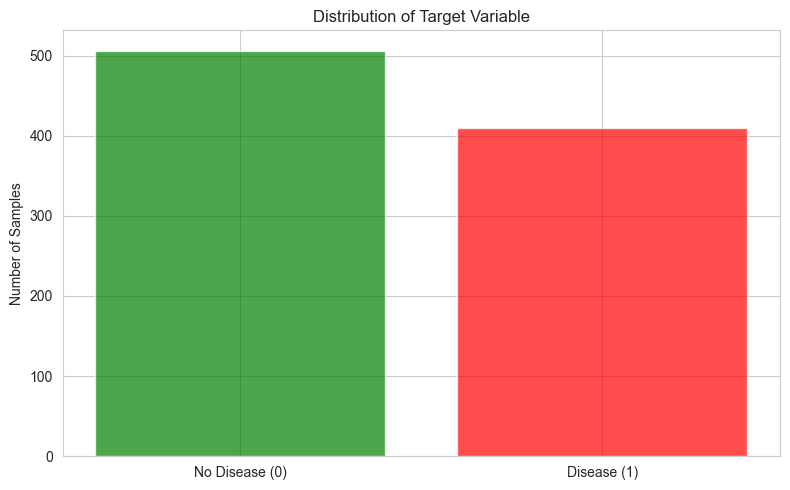


The data is fairly balanced - about 54% have disease, 46% don't


In [68]:
# Check target variable distribution
print("Target variable value counts:")
print(df['target'].value_counts())
print(f"\nPercentages:")
print(df['target'].value_counts(normalize=True) * 100)

# Visualize the distribution
plt.figure(figsize=(8, 5))
counts = df['target'].value_counts()
plt.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['green', 'red'], alpha=0.7)
plt.ylabel('Number of Samples')
plt.title('Distribution of Target Variable')
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=100)
plt.show()

print("\nThe data is fairly balanced - about 54% have disease, 46% don't")

## Step 4: Visualize Feature Distributions

Let's look at how the features are distributed. This helps us understand the data and identify any potential issues.

In [69]:
import sys

# Calculate data size
data_size_bytes = df.memory_usage(deep=True).sum()
data_size_kb = data_size_bytes / 1024

print(f"Dataset Memory Size: {data_size_kb:.2f} KB")
print(f"Number of Rows: {len(df)}")
print(f"Number of Features: {len(df.columns)}")
print(f"Rows × Features: {len(df) * len(df.columns)}")
print(f"\nMemory per column (KB):")
print(df.memory_usage(deep=True) / 1024)

Dataset Memory Size: 100.32 KB
Number of Rows: 916
Number of Features: 14
Rows × Features: 12824

Memory per column (KB):
Index       0.128906
age         7.156250
sex         7.156250
cp          7.156250
trestbps    7.156250
chol        7.156250
fbs         7.156250
restecg     7.156250
thalach     7.156250
exang       7.156250
oldpeak     7.156250
slope       7.156250
ca          7.156250
thal        7.156250
target      7.156250
dtype: float64


## 5. Feature Distributions & Class Balance

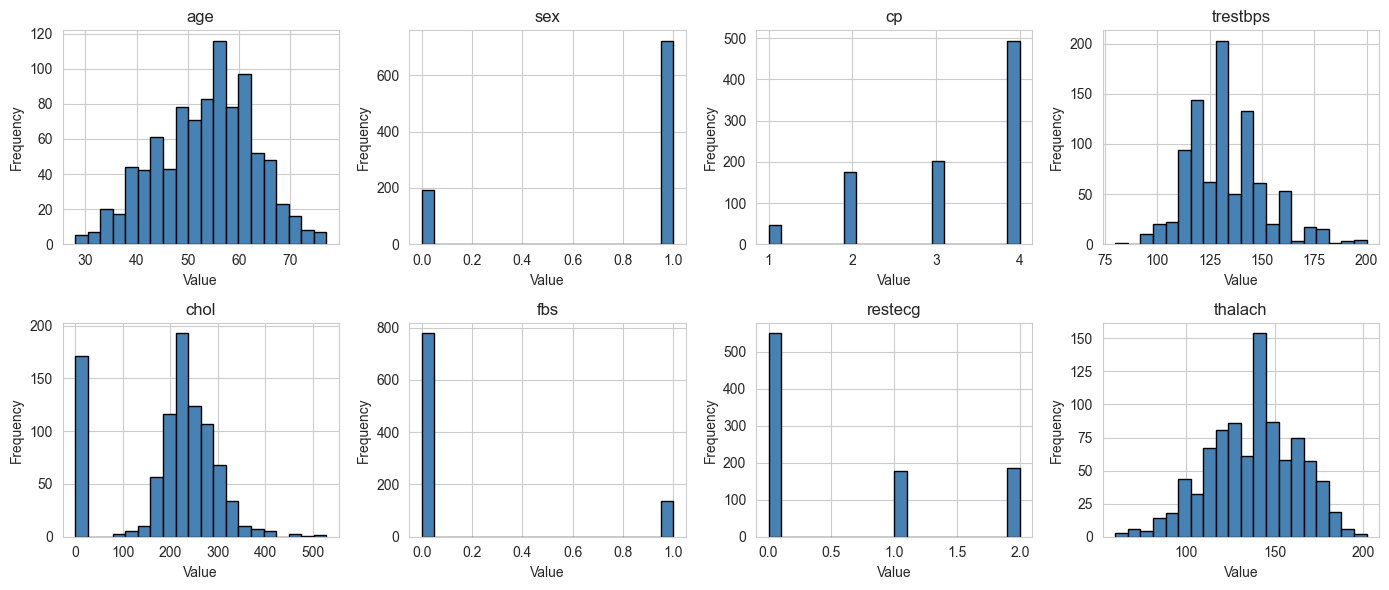

Most features look reasonably distributed


In [70]:
# Plot distributions for the first 8 features
features_to_plot = df.columns[:-1][:8]  # Get first 8 features (exclude target)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()

for idx, col in enumerate(features_to_plot):
    axes[idx].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions_1.png', dpi=100)
plt.show()

print("Most features look reasonably distributed")

## Step 5: Correlation with Target Variable

Which features are most correlated with heart disease?

Correlation of features with target (heart disease):
target      1.000000
cp          0.471382
exang       0.434571
oldpeak     0.367361
sex         0.307786
thal        0.289392
age         0.284356
slope       0.204007
ca          0.162797
trestbps    0.109279
fbs         0.106628
restecg     0.064548
chol       -0.230473
thalach    -0.382351
Name: target, dtype: float64


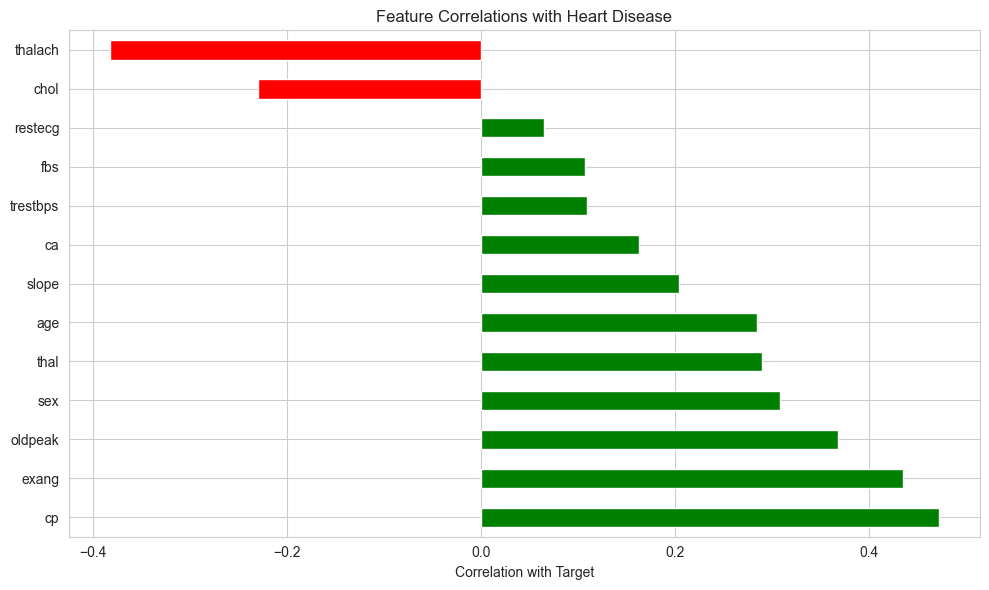


Top predictive features:
cp         0.471382
exang      0.434571
oldpeak    0.367361
sex        0.307786
thal       0.289392
age        0.284356
slope      0.204007
Name: target, dtype: float64


In [71]:
# Calculate correlations with target
correlations = df.corr()['target'].sort_values(ascending=False)

print("Correlation of features with target (heart disease):")
print(correlations)

# Visualize the correlations
plt.figure(figsize=(10, 6))
correlations[1:].plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations[1:]])
plt.xlabel('Correlation with Target')
plt.title('Feature Correlations with Heart Disease')
plt.tight_layout()
plt.savefig('../reports/figures/correlations.png', dpi=100)
plt.show()

print("\nTop predictive features:")
print(correlations[1:8])  # Show top 7 (excluding target itself)

## Step 6: Check for Outliers and Data Issues

Let's look at the ranges of features to identify potential outliers or scaling issues.

Feature ranges:
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
min  28.0  0.0  1.0      80.0    0.0  0.0      0.0     60.0    0.0     -2.6   
max  77.0  1.0  4.0     200.0  529.0  1.0      2.0    202.0    1.0      5.6   

     slope   ca  thal  target  
min    1.0  0.0   3.0     0.0  
max    3.0  3.0   7.0     1.0  


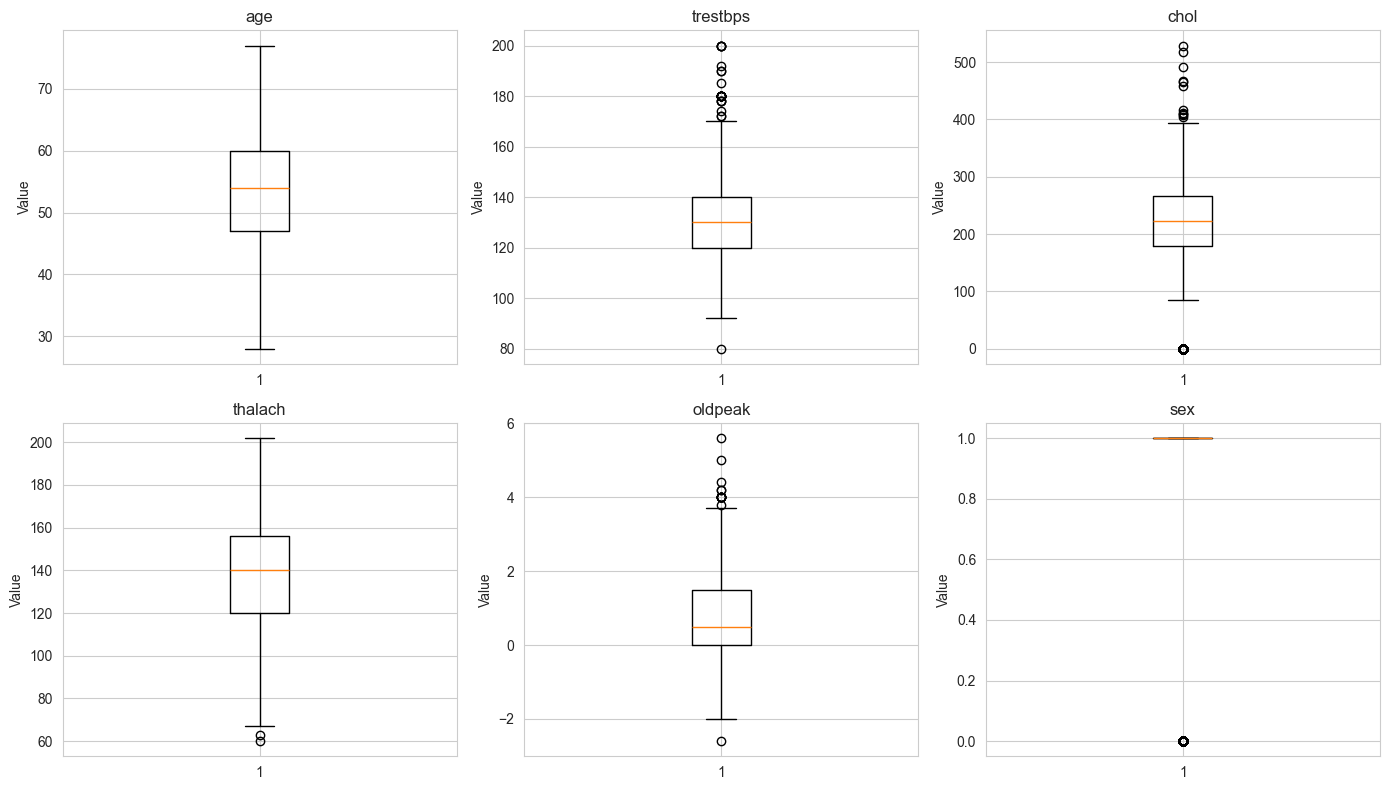


Some observations:
- Cholesterol (chol) has quite a range (0-529)
- Most other features are reasonably scaled
- We'll need to scale features for algorithms like Logistic Regression


In [72]:
# Look at feature ranges - useful for identifying scaling needs
print("Feature ranges:")
print(df.describe().loc[['min', 'max']])

# Check if there are obvious outliers using boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

features_to_check = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex']
for idx, col in enumerate(features_to_check):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../reports/figures/outlier_check.png', dpi=100)
plt.show()

print("\nSome observations:")
print("- Cholesterol (chol) has quite a range (0-529)")
print("- Most other features are reasonably scaled")
print("- We'll need to scale features for algorithms like Logistic Regression")

## Step 7: Summary and Next Steps

Let me summarize what we found and what we need to do next.

In [73]:
# Summary of findings from EDA

print("EXPLORATORY DATA ANALYSIS SUMMARY")

print("\n1. DATA QUALITY:")
print(f"   - Dataset shape: {df.shape[0]} samples, {df.shape[1]} features")
print(f"   - Missing values: {df.isnull().sum().sum()} (None!)")
print(f"   - No data quality issues identified")

print("\n2. TARGET VARIABLE:")
print(f"   - Disease present: {(df['target'] == 1).sum()} samples ({(df['target'] == 1).sum() / len(df) * 100:.1f}%)")
print(f"   - No disease: {(df['target'] == 0).sum()} samples ({(df['target'] == 0).sum() / len(df) * 100:.1f}%)")
print(f"   - Balanced classes - good for modeling")

print("\n3. FEATURES:")
print(f"   - Total features: {len(df.columns) - 1}")
print(f"   - Most predictive (by correlation):")
top_features = df.corr()['target'].drop('target').abs().sort_values(ascending=False).head(5)
for feat, corr in top_features.items():
    print(f"     * {feat}: {corr:.3f}")

print("\n4. SCALING CONSIDERATIONS:")
print("   - Features have different ranges (chol: 0-529, age: 28-77, sex: 0-1)")
print("   - Will need to scale features before training models")
print("   - Some algorithms (trees) don't need scaling, but LR, SVM do")

print("\n5. NEXT STEPS:")
print("   - Scale numerical features")
print("   - Create train/test split")
print("   - Build and train multiple models")
print("   - Evaluate model performance")

EXPLORATORY DATA ANALYSIS SUMMARY

1. DATA QUALITY:
   - Dataset shape: 916 samples, 14 features
   - Missing values: 0 (None!)
   - No data quality issues identified

2. TARGET VARIABLE:
   - Disease present: 506 samples (55.2%)
   - No disease: 410 samples (44.8%)
   - Balanced classes - good for modeling

3. FEATURES:
   - Total features: 13
   - Most predictive (by correlation):
     * cp: 0.471
     * exang: 0.435
     * thalach: 0.382
     * oldpeak: 0.367
     * sex: 0.308

4. SCALING CONSIDERATIONS:
   - Features have different ranges (chol: 0-529, age: 28-77, sex: 0-1)
   - Will need to scale features before training models
   - Some algorithms (trees) don't need scaling, but LR, SVM do

5. NEXT STEPS:
   - Scale numerical features
   - Create train/test split
   - Build and train multiple models
   - Evaluate model performance


## Additional Observations

A few more things worth noting about the dataset.

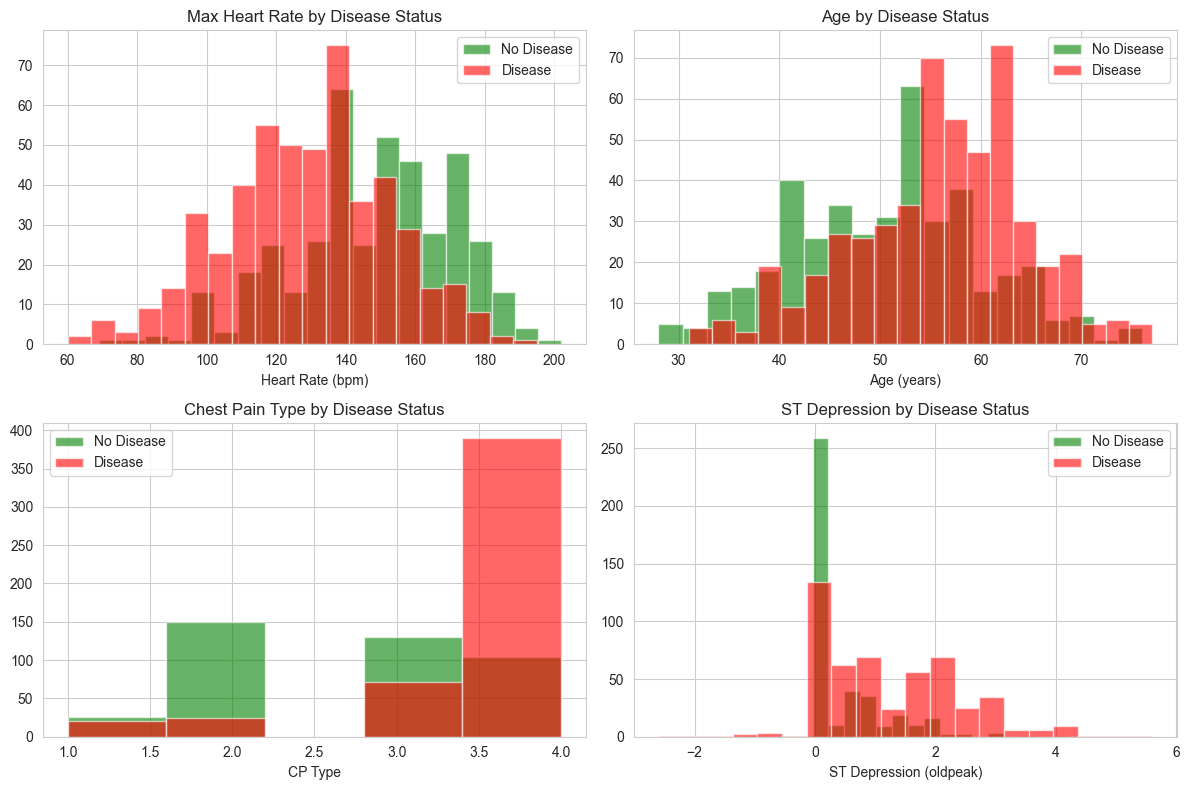

In [74]:
# Look at feature relationships with the target
# Let's compare some key features between disease and non-disease groups

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Feature 1: Maximum heart rate achieved (thalach)
axes[0, 0].hist(df[df['target']==0]['thalach'], bins=20, alpha=0.6, label='No Disease', color='green')
axes[0, 0].hist(df[df['target']==1]['thalach'], bins=20, alpha=0.6, label='Disease', color='red')
axes[0, 0].set_title('Max Heart Rate by Disease Status')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Heart Rate (bpm)')

# Feature 2: Age
axes[0, 1].hist(df[df['target']==0]['age'], bins=20, alpha=0.6, label='No Disease', color='green')
axes[0, 1].hist(df[df['target']==1]['age'], bins=20, alpha=0.6, label='Disease', color='red')
axes[0, 1].set_title('Age by Disease Status')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Age (years)')

# Feature 3: Chest pain type (cp)
axes[1, 0].hist(df[df['target']==0]['cp'], bins=5, alpha=0.6, label='No Disease', color='green')
axes[1, 0].hist(df[df['target']==1]['cp'], bins=5, alpha=0.6, label='Disease', color='red')
axes[1, 0].set_title('Chest Pain Type by Disease Status')
axes[1, 0].legend()
axes[1, 0].set_xlabel('CP Type')

# Feature 4: ST depression (oldpeak)
axes[1, 1].hist(df[df['target']==0]['oldpeak'], bins=20, alpha=0.6, label='No Disease', color='green')
axes[1, 1].hist(df[df['target']==1]['oldpeak'], bins=20, alpha=0.6, label='Disease', color='red')
axes[1, 1].set_title('ST Depression by Disease Status')
axes[1, 1].legend()
axes[1, 1].set_xlabel('ST Depression (oldpeak)')

plt.tight_layout()
plt.savefig('../reports/figures/features_by_target.png', dpi=100)
plt.show()
